In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import MinMaxScaler



---


# Data Import & Preproccess

Importing data & checking for nulls/duplicates

## Import, read & clean Data

In [ ]:
loan_data = pd.read_csv("/content/sample_data/loan_data.csv")
print(loan_data.info())
print()
print("Duplicates: ",loan_data.duplicated().sum())
loan_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
loan_data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Scaling data

In [ ]:
# Create X (all the feature columns)
X = loan_data.drop(["loan_status","person_gender","person_education","person_emp_exp","cb_person_cred_hist_length","person_age","loan_intent"], axis=1)

# Create y (the target column)
y = loan_data["loan_status"]

# Check the head of the features DataFrame
X.head()

,person_income,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,71948.0,RENT,35000.0,16.02,0.49,561,No
1,12282.0,OWN,1000.0,11.14,0.08,504,Yes
2,12438.0,MORTGAGE,5500.0,12.87,0.44,635,No
3,79753.0,RENT,35000.0,15.23,0.44,675,No
4,66135.0,RENT,35000.0,14.27,0.53,586,No


In [ ]:
scaler = MinMaxScaler()

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X.head()

,person_income,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,0.008891,RENT,1.000000,0.727023,0.742424,0.371739,No
1,0.000595,OWN,0.014493,0.392318,0.121212,0.247826,Yes
2,0.000617,MORTGAGE,0.144928,0.510974,0.666667,0.532609,No
3,0.009976,RENT,1.000000,0.672840,0.666667,0.619565,No
4,0.008082,RENT,1.000000,0.606996,0.803030,0.426087,No


## Encoding Categorical Data

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 2. Define the categorical features to transform
categorical_features = ["person_home_ownership","previous_loan_defaults_on_file"]

# 3. Create an instance of OneHotEncoder
one_hot = OneHotEncoder()

# 4. Create an instance of ColumnTransformer
transformer = ColumnTransformer([("one_hot", # name
                                  one_hot, # transformer
                                  categorical_features)], # columns to transform
                                  remainder="passthrough") # what to do with the rest of the columns? ("passthrough" = leave unchanged)

# 5. Turn the categorical features into numbers (this will return an array-like sparse matrix, not a DataFrame)
transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.        , 0.        , 0.        , ..., 0.72702332, 0.74242424,
        0.37173913],
       [0.        , 0.        , 1.        , ..., 0.39231824, 0.12121212,
        0.24782609],
       [1.        , 0.        , 0.        , ..., 0.51097394, 0.66666667,
        0.5326087 ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.31550069, 0.07575758,
        0.60434783],
       [0.        , 0.        , 0.        , ..., 0.53566529, 0.54545455,
        0.46521739],
       [0.        , 0.        , 0.        , ..., 0.79766804, 0.1969697 ,
        0.5173913 ]])



---


#  Data Splitting

Splitting the data into training, validation and test sets

## Split into 3

In [ ]:
from sklearn.model_selection import train_test_split

#train = 0.8, test=0.2
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

#train = 0.6, val=0.2   (0.8*0.25)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape

((27000, 11), (9000, 11), (9000, 11), (27000,), (9000,), (9000,))



---


# KNN



## Test the model performance by trying different values of K.

In [ ]:
# evaluation metrics import
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# evaluate predictions using several common classification metrics

def evaluate_preds(y_true, y_preds):

     accuracy = accuracy_score(y_true, y_preds) # accuracy: proportion of correct predictions
     precision = precision_score(y_true, y_preds) # Precision: how many of the predicted positives are actual positives
     recall = recall_score(y_true, y_preds) # Recall: how many of the actual positives were correctly identified
     f1 = f1_score(y_true, y_preds) # F1 score: harmonic mean of precision and recall

     metric_dict = {
         "accuracy": round(accuracy, 2),
         "precision": round(precision, 2),
         "recall": round(recall, 2),
         "f1": round(f1, 2)
         }
     return metric_dict

## Use the validation set to find the optimal K value.

In [ ]:
# Manual search for the best value of K
score_arr_to_plot = []
for K in range(1,21):
    model = KNeighborsClassifier(n_neighbors=K)
    model.fit(X_train, y_train)
    y_preds = model.predict(X_val)

    score_arr_to_plot.append(model.score(X_val, y_val))
    print(f"For K={K}, score is {model.score(X_val, y_val)}")
    print(f"{evaluate_preds(y_val, y_preds)}")
    print("====================================================")
    print()


For K=1, score is 0.8813333333333333
{'accuracy': 0.88, 'precision': 0.73, 'recall': 0.74, 'f1': 0.74}

For K=2, score is 0.8917777777777778
{'accuracy': 0.89, 'precision': 0.85, 'recall': 0.62, 'f1': 0.72}

For K=3, score is 0.896
{'accuracy': 0.9, 'precision': 0.78, 'recall': 0.75, 'f1': 0.76}

For K=4, score is 0.9005555555555556
{'accuracy': 0.9, 'precision': 0.85, 'recall': 0.68, 'f1': 0.75}

For K=5, score is 0.9046666666666666
{'accuracy': 0.9, 'precision': 0.81, 'recall': 0.75, 'f1': 0.78}

For K=6, score is 0.9068888888888889
{'accuracy': 0.91, 'precision': 0.85, 'recall': 0.71, 'f1': 0.77}

For K=7, score is 0.9081111111111111
{'accuracy': 0.91, 'precision': 0.82, 'recall': 0.75, 'f1': 0.79}

For K=8, score is 0.9083333333333333
{'accuracy': 0.91, 'precision': 0.85, 'recall': 0.72, 'f1': 0.78}

For K=9, score is 0.9082222222222223
{'accuracy': 0.91, 'precision': 0.83, 'recall': 0.75, 'f1': 0.78}

For K=10, score is 0.9092222222222223
{'accuracy': 0.91, 'precision': 0.86, 'rec

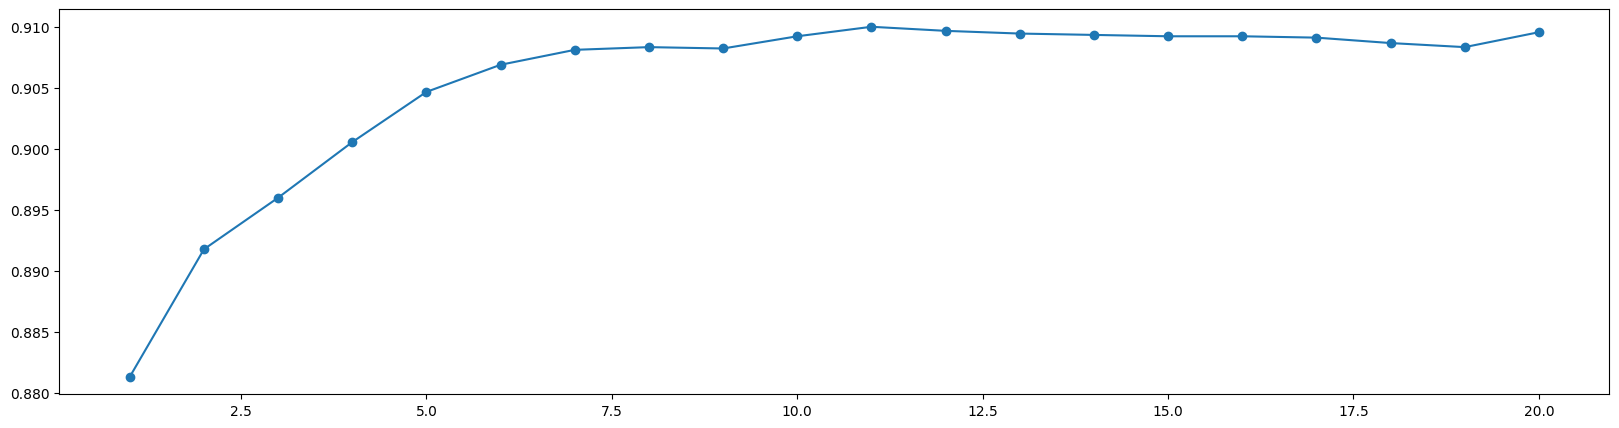

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(np.arange(1, 21, 1), score_arr_to_plot, marker='o')
plt.show()

In [ ]:
model= KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

# Cross-Validation

Apply k-Fold Cross-Validation on the training set.

In [ ]:
from sklearn.model_selection import GridSearchCV
# Selecting the best k automatically
grid ={"n_neighbors": [11],
       "weights":  ['uniform'],
       'p': [1],
       "algorithm": ['brute'],
       "leaf_size": [2]}

gs_model = GridSearchCV(
    estimator=model,
    param_grid=grid,
    cv=5, # 5-fold cross-validation: splits training data into 5 parts
    verbose=2
    )
gs_model.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END algorithm=brute, leaf_size=2, n_neighbors=11, p=1, weights=uniform; total time=   2.1s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=11, p=1, weights=uniform; total time=   1.7s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=11, p=1, weights=uniform; total time=   1.7s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=11, p=1, weights=uniform; total time=   1.7s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=11, p=1, weights=uniform; total time=   1.7s


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=11),
             param_grid={'algorithm': ['brute'], 'leaf_size': [2],
                         'n_neighbors': [11], 'p': [1],
                         'weights': ['uniform']},
             verbose=2)

In [ ]:
gs_model.best_params_

{'algorithm': 'brute',
 'leaf_size': 2,
 'n_neighbors': 11,
 'p': 1,
 'weights': 'uniform'}

In [ ]:
# Convert results to a DataFrame
results_df = pd.DataFrame(gs_model.cv_results_)

# Show mean test scores for each parameter combination
results_df[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'algorithm': 'brute', 'leaf_size': 2, 'n_neig...",0.906481,1


In [ ]:
Average_accuracy_across_folds = results_df[['params', 'mean_test_score', 'rank_test_score']]["mean_test_score"].mean()
Average_accuracy_across_folds

np.float64(0.9064814814814814)

## Comparison

In [ ]:
from sklearn.model_selection import cross_val_score


# 5-fold cross-validation on current model using  TRAINING set
# so it returns array of accuracy scores per fold
model_cross_val_score = cross_val_score(model, X_train, y_train, cv=5)
model_cross_val_score

array([0.9062963 , 0.89981481, 0.90666667, 0.90111111, 0.91185185])

In [ ]:
model_cross_val_score.mean() # Average

np.float64(0.9051481481481481)

In [ ]:
print(f"Average model cross validation {model_cross_val_score.mean()}")
print(f"Validation accuracy: {model.score(X_val, y_val)}")
print(f"Test-set accuracy: {model.score(X_test, y_test)}")

Average model cross validation 0.9051481481481481
Validation accuracy: 0.91
Test-set accuracy: 0.9055555555555556


-> Discuss if cross-validation gives a more robust performance estimate.

Cross-Validation is very close to the the validaation & test sets, showing that it is a reliable estimate

# Confusion Matrix

## Evaluation

In [ ]:
gs_y_preds = gs_model.predict(X_test)
 # evaluate the predictions
gs_metrics = evaluate_preds(y_test, gs_y_preds)
gs_metrics


{'accuracy': 0.91, 'precision': 0.82, 'recall': 0.75, 'f1': 0.78}

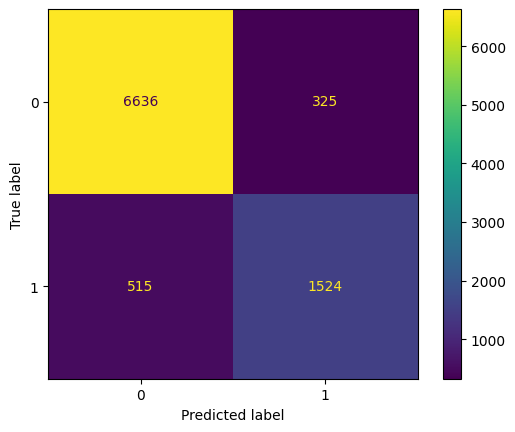

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=gs_y_preds
    );

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true=y_test,
    y_pred=gs_y_preds,
    digits=4
    ))

              precision    recall  f1-score   support

           0     0.9280    0.9533    0.9405      6961
           1     0.8242    0.7474    0.7840      2039

    accuracy                         0.9067      9000
   macro avg     0.8761    0.8504    0.8622      9000
weighted avg     0.9045    0.9067    0.9050      9000



In [ ]:
gs_y_preds_train =gs_model.predict(X_train)
print(classification_report(
    y_true=y_train,
    y_pred=gs_y_preds_train,
    digits=4
    ))

              precision    recall  f1-score   support

           0     0.9359    0.9636    0.9496     21056
           1     0.8560    0.7662    0.8086      5944

    accuracy                         0.9201     27000
   macro avg     0.8960    0.8649    0.8791     27000
weighted avg     0.9183    0.9201    0.9185     27000



## Analyze
Both models predict false-negative more than false-positive.

# Overfitting and Model Improvement.

## Discuss possible overfitting issues.
When training accuracy is higher than test's accuracy, overfitting occures. We solve this through cross-validation (regularization) or tune K values or perform feature engineering.

## Techniques to reduce overfitting.

In [ ]:
model_2= KNeighborsClassifier(n_neighbors=17)
model_2.fit(X_train, y_train)

grid_2 ={"n_neighbors": [17],
       "weights":  ['uniform'],
       'p': [1],
       "algorithm": ['brute'],
       "leaf_size": [2]}

gs_model_2 = GridSearchCV(
    estimator=model_2,
    param_grid=grid_2,
    cv=5, # 5-fold cross-validation: splits training data into 5 parts
    verbose=2
    )
gs_model_2.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END algorithm=brute, leaf_size=2, n_neighbors=17, p=1, weights=uniform; total time=   1.8s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=17, p=1, weights=uniform; total time=   2.2s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=17, p=1, weights=uniform; total time=   2.4s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=17, p=1, weights=uniform; total time=   1.7s
[CV] END algorithm=brute, leaf_size=2, n_neighbors=17, p=1, weights=uniform; total time=   1.7s


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=17),
             param_grid={'algorithm': ['brute'], 'leaf_size': [2],
                         'n_neighbors': [17], 'p': [1],
                         'weights': ['uniform']},
             verbose=2)

In [ ]:
gs_y_preds_2 = gs_model_2.predict(X_test)

In [ ]:
print(classification_report(
    y_true=y_test,
    y_pred=gs_y_preds_2,
    digits=4
    ))

              precision    recall  f1-score   support

           0     0.9262    0.9550    0.9404      6961
           1     0.8282    0.7401    0.7817      2039

    accuracy                         0.9063      9000
   macro avg     0.8772    0.8476    0.8610      9000
weighted avg     0.9040    0.9063    0.9044      9000



In [ ]:
gs_y_preds_train_2 = gs_model_2.predict(X_train)
print(classification_report(
    y_true=y_train,
    y_pred=gs_y_preds_train_2,
    digits=4
    ))

              precision    recall  f1-score   support

           0     0.9320    0.9643    0.9479     21056
           1     0.8558    0.7507    0.7998      5944

    accuracy                         0.9173     27000
   macro avg     0.8939    0.8575    0.8738     27000
weighted avg     0.9152    0.9173    0.9153     27000



# Visualization

## Confusion Matrix (Heatmap) for KNN model

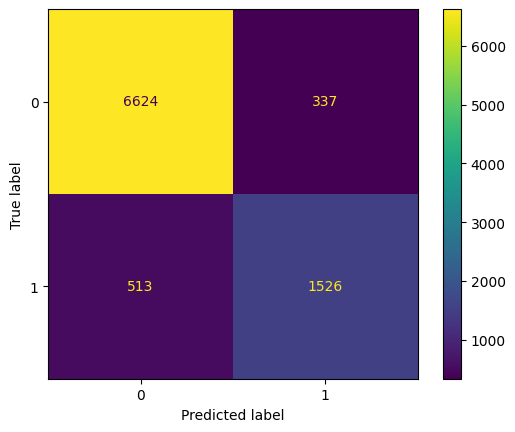

In [ ]:
model_y_preds = model.predict(X_test)
# evaluate the predictions
model_metrics = evaluate_preds(y_test, gs_y_preds)
model_metrics

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=model_y_preds
    );